# Visualize datasets

In [34]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import plotly.graph_objects as go

## Ellipsoide

In [35]:
# Load the data
mat_ellips = scipy.io.loadmat('datasets/datasets/ellipsoide_standardpca.mat')
X_ellips = mat_ellips['X']
n = X_ellips.shape[0]
d = X_ellips.shape[1]

print('n,d:',n,d)

n,d: 1000 100


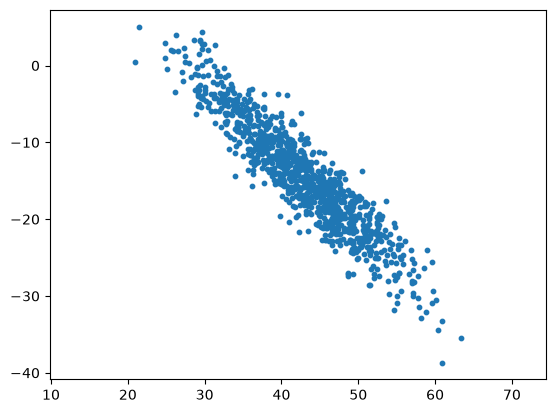

In [36]:
# Plot the data in 2D
plt.scatter(X_ellips[:,0], X_ellips[:,1], s=10)
plt.axis('equal')
plt.show()

In [37]:
# Plot the data in 2D
Xvis, Yvis, Zvis = X_ellips[:,0], X_ellips[:,1], X_ellips[:,2]
data = go.Scatter3d(x=Xvis, y=Yvis, z=Zvis, mode='markers', marker=dict(size=3, colorscale='jet', opacity=1)) # data as points
fig = go.Figure(data=[data]) 
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30, pad=0)) # tight layout but t=25 required for showing title 
fig.update_layout(autosize=False, width=600, height=600, title_text="Ellipsoide") # figure size and title
fig.update_layout(scene = dict(zaxis = dict(showgrid = True, showticklabels = False), zaxis_title = ' ') ) # no range values, no axis name, grid on
fig.update_layout(scene = dict(yaxis = dict(showgrid = True, showticklabels = False), yaxis_title = ' ') ) # no range values, no axis name, grid on
fig.update_layout(scene = dict(xaxis = dict(showgrid = True, showticklabels = False), xaxis_title = ' ') ) # no range values, no axis name, grid on
fig.layout.scene.aspectratio = {'x':1, 'y':1, 'z':1}
fig.show()

## yale_faces

In [38]:
# Load the data
mat_yale = scipy.io.loadmat('datasets/datasets/yale_faces.mat')
X_yale = mat_yale['X']
n = X_yale.shape[0]
d = X_yale.shape[1]
Nx = mat_yale['Nx_downscale'].squeeze()
Ny = mat_yale['Ny_downscale'].squeeze()
Cgt_yale = mat_yale['Cgt'].squeeze()

print('n,d:',n,d)
print('face size x={} y={}'.format(Nx,Ny))

n,d: 27 3465
face size x=55 y=63


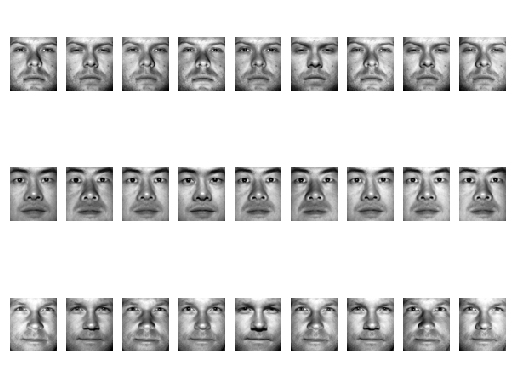

In [39]:
plt.figure(1)
for human in range(0,3):
    for face in range(0,9):
        plt.subplot(3,9,human*9+face+1)
        rotated_img = scipy.ndimage.rotate(np.reshape(X_yale[human*9+face,:],[Nx,Ny]), -90)
        plt.imshow(rotated_img, interpolation='nearest', cmap='Greys_r')
        plt.axis('equal')
        plt.axis('off')
plt.show()

## Swiss roll

In [40]:
# Swiss roll data
mat_roll = scipy.io.loadmat('datasets/datasets/swiss_roll.mat')
X_roll = mat_roll['X']
n = X_roll.shape[0]
d = X_roll.shape[1]
Cgt_roll = mat_roll['Cgt'].squeeze()

print('n,d:',n,d)

n,d: 2048 3


In [41]:
Xvis, Yvis, Zvis = X_roll[:,0], X_roll[:,1], X_roll[:,2]
Ccolor = ['rgb('+str(c[0]*255)+', '+str(c[1]*255)+', '+str(c[2]*255)+')' for c in Cgt_roll]

# 3D Visualization
data = go.Scatter3d(x=Xvis, y=Yvis, z=Zvis, mode='markers', marker=dict(size=3, color=Ccolor, colorscale='jet', opacity=1)) # data as points
fig = go.Figure(data=[data]) 
fig.update_layout(margin=dict(l=0, r=0, b=0, t=30, pad=0)) # tight layout but t=25 required for showing title 
fig.update_layout(autosize=False, width=600, height=600, title_text="Swiss roll") # figure size and title
fig.update_layout(scene = dict(zaxis = dict(showgrid = True, showticklabels = False), zaxis_title = ' ') ) # no range values, no axis name, grid on
fig.update_layout(scene = dict(yaxis = dict(showgrid = True, showticklabels = False), yaxis_title = ' ') ) # no range values, no axis name, grid on
fig.update_layout(scene = dict(xaxis = dict(showgrid = True, showticklabels = False), xaxis_title = ' ') ) # no range values, no axis name, grid on
fig.layout.scene.aspectratio = {'x':1, 'y':1, 'z':1}
fig.show()

## MNIST

In [42]:
# MNIST dataset
mat_mnist = scipy.io.loadmat('datasets/datasets/MNIST_data.mat')
X_mnist = mat_mnist['X']
n = X_mnist.shape[0]
d = X_mnist.shape[1]
C = mat_mnist['C'].squeeze()

print('n,d:',n,d)

n,d: 60000 784


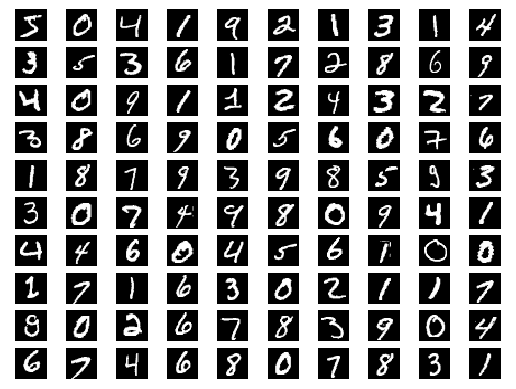

In [43]:
nb_line = 10
nb_col = 10
plt.figure(1)
for digit in range(0,nb_line*nb_col):
    plt.subplot(nb_line,nb_col,digit+1)
    #rotated_img = scipy.ndimage.rotate(np.reshape(X[human*9+face,:],[Nx,Ny]), -90)
    img = np.reshape(X_mnist[digit,:],[28,28])
    # transform image (symetry over diagonal)
    rotated_img = np.zeros((28,28))
    for i in range(28):
        for j in range(28):
            rotated_img[i,j] = img[j,i]
    #rotated_img = scipy.ndimage.rotate(img, -90)
    plt.imshow(rotated_img, interpolation='nearest', cmap='Greys_r')
    plt.axis('equal')
    plt.axis('off')
plt.show()